# Training - Logistic Regression

**Dataset options** (set `DATASET` below):
- `cresci_2015`
- `cresci_2017`
- `twibot_2020`
- `twibot_2022`


## 0. Config


In [77]:
DATASET = "cresci_2017"   # cresci_2015 | cresci_2017 | twibot_2020 | twibot_2022

DATASET_PATHS = {
    "cresci_2015": "/Users/hsla/Desktop/data/processed/cresci_2015/users_cresci_2015.csv",
    "cresci_2017": "/Users/hsla/Desktop/data/processed/cresci_2017/users_cresci_2017.csv",
    "twibot_2020": "/Users/hsla/Desktop/data/processed/twibot_2020/users_twibot_20.csv",
    "twibot_2022": "/Users/hsla/Desktop/data/processed/twibot_2022/users_twibot_22.csv",
}

MODEL_OUT = f"/Users/hsla/Desktop/{DATASET}_logisticRegression.pkl"

USERS_CSV = DATASET_PATHS[DATASET]

RANDOM_STATE = 42
TEST_SIZE    = 0.20   # 80 / 20 train-test split

print(f"Dataset : {DATASET}")
print(f"File    : {USERS_CSV}")
print(f"Model   → {MODEL_OUT}")


Dataset : cresci_2017
File    : /Users/hsla/Desktop/data/processed/cresci_2017/users_cresci_2017.csv
Model   → /Users/hsla/Desktop/cresci_2017_logisticRegression.pkl


In [78]:
%pip install matplotlib seaborn scikit-learn pandas numpy


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 1. Imports


In [79]:
import os, pickle
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model       import LogisticRegression
from sklearn.model_selection    import train_test_split, cross_val_score
from sklearn.metrics            import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay,
)
from sklearn.pipeline           import Pipeline
from sklearn.impute             import SimpleImputer
from sklearn.preprocessing      import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
print("Imports OK")


Imports OK


## 2. Load data


In [80]:
df = pd.read_csv(USERS_CSV)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
print("\nLabel distribution:")
print(df["label"].value_counts())
df.head(3)


Loaded 14,368 rows × 15 columns

Label distribution:
label
bot      10894
human     3474
Name: count, dtype: int64


,user_id,screen_name,label,subset,followers_count,friends_count,statuses_count,favourites_count,listed_count,created_at,verified,description,location,default_profile_image,source
0,1502026416,0918Bask,human,genuine_accounts.csv,208,332,2177,265,1,Tue Jun 11 11:20:35 +0000 2013,NaN,15years ago X.Lines24,Tokyo .Japan .,NaN,cresci_2017
1,2492782375,1120Roll,human,genuine_accounts.csv,330,485,2660,3972,5,Tue May 13 10:37:57 +0000 2014,NaN,ä¿å®è¦ç¿ãå°å å¤§å¥½ãäººéã çµæ¸...,ç¥å¥å·çæ¨ªæµå¸,NaN,cresci_2017
2,293212315,14KBBrown,human,genuine_accounts.csv,166,177,1254,1185,0,Wed May 04 23:30:37 +0000 2011,NaN,Let me see what your best move is!,NaN,NaN,cresci_2017


## 3. Feature engineering


In [ ]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Return a feature matrix (one row per user)."""
    feat = pd.DataFrame(index=df.index)

    feat["followers_count"]  = pd.to_numeric(df["followers_count"],  errors="coerce")
    feat["friends_count"]    = pd.to_numeric(df["friends_count"],    errors="coerce")
    feat["statuses_count"]   = pd.to_numeric(df["statuses_count"],   errors="coerce")
    feat["favourites_count"] = pd.to_numeric(df["favourites_count"], errors="coerce")
    feat["listed_count"]     = pd.to_numeric(df["listed_count"],     errors="coerce")

    # follower/friend ratio
    feat["ff_ratio"] = (
        feat["followers_count"] /
        (feat["friends_count"] + 1)
    )

    # tweets per day since the account was created
    created = pd.to_datetime(df["created_at"], errors="coerce", utc=True, format="mixed")
    age_days = (pd.Timestamp.utcnow() - created).dt.days.clip(lower=30)
    feat["tweet_rate"] = feat["statuses_count"] / age_days

    feat["account_age_days"] = age_days

    feat["verified"] = (
        df["verified"].astype(str).str.strip().str.lower()
        .map({"true": 1, "1": 1, "false": 0, "0": 0})
        .fillna(0).astype(int)
    )
    feat["default_profile_image"] = (
        pd.to_numeric(df["default_profile_image"], errors="coerce")
        .fillna(0).astype(int)
    )

    feat["desc_len"]        = df["description"].fillna("").str.len()
    feat["has_description"] = (feat["desc_len"] > 0).astype(int)
    feat["has_location"]    = df["location"].notna().astype(int)

    return feat


X = build_features(df)
X = X.replace([np.inf, -np.inf], np.nan)
X["tweet_rate"] = X["tweet_rate"].clip(upper=X["tweet_rate"].quantile(0.99))
y = (df["label"] == "bot").astype(int)

print(f"Feature matrix: {X.shape}")
print(f"Bot rate      : {y.mean():.1%}")
X.describe().T.round(2)


Feature matrix: (14368, 13)
Bot rate      : 75.8%


,count,mean,std,min,25%,50%,75%,max
followers_count,14368.0,868.28,26884.72,0.0,6.00,25.00,332.00,2991573.00
friends_count,14368.0,589.32,2665.83,0.0,42.00,250.00,538.00,211890.00
statuses_count,14368.0,5063.19,17493.41,0.0,31.00,63.00,1365.25,399555.00
favourites_count,14368.0,1145.29,6036.89,0.0,0.00,0.00,9.00,313954.00
listed_count,14368.0,11.17,266.97,0.0,0.00,0.00,3.00,24348.00
ff_ratio,14368.0,1.57,37.49,0.0,0.06,0.20,0.96,3595.75
tweet_rate,13368.0,0.92,2.39,0.0,0.01,0.01,0.40,14.58
account_age_days,13368.0,5048.10,634.60,3804.0,4451.00,4969.00,5413.25,7039.00
verified,14368.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00
default_profile_image,14368.0,0.01,0.07,0.0,0.00,0.00,0.00,1.00


## 4. Train / test split


In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,
)

print(f"Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows")
print(f"Bot rate in train: {y_train.mean():.1%}  |  test: {y_test.mean():.1%}")


Train: 11,494 rows  |  Test: 2,874 rows
Bot rate in train: 75.8%  |  test: 75.8%


## 5. Build and train the model


In [ ]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=0.1,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="lbfgs",
    )),
])

pipeline.fit(X_train, y_train)
print("Training complete")


Training complete


/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_streng

## 6. Evaluate on the held-out test set


In [84]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("=" * 50)
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["human", "bot"]))

ROC-AUC : 0.9168
              precision    recall  f1-score   support

       human       0.87      0.74      0.80       695
         bot       0.92      0.96      0.94      2179

    accuracy                           0.91      2874
   macro avg       0.89      0.85      0.87      2874
weighted avg       0.91      0.91      0.91      2874



/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


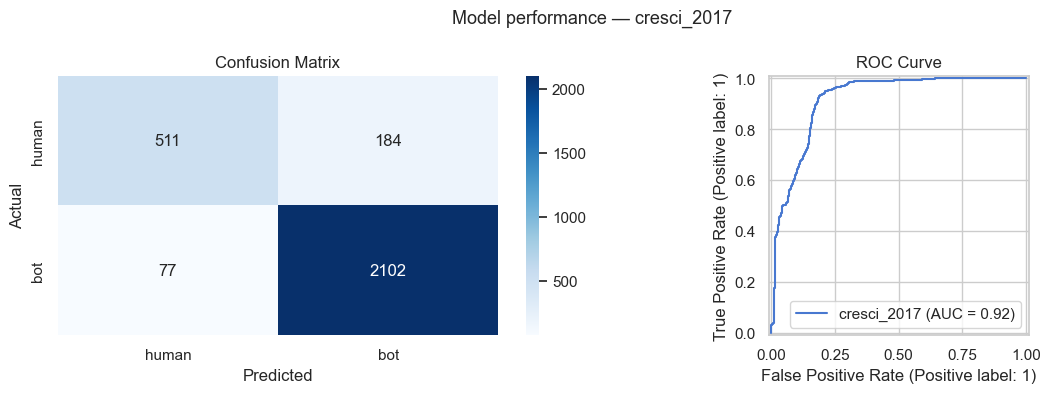

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["human", "bot"],
    yticklabels=["human", "bot"],
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=DATASET)
axes[1].set_title("ROC Curve")

plt.suptitle(f"Model performance — {DATASET}", fontsize=13)
plt.tight_layout()
plt.show()


## 7. Cross-validation


In [86]:
cv_scores = cross_val_score(
    pipeline,
    X, y,
    cv=5, scoring="roc_auc", n_jobs=-1,
)

print(f"5-fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Individual folds : {np.round(cv_scores, 4)}")


5-fold CV ROC-AUC: 0.8957 ± 0.0618
Individual folds : [0.9102 0.866  0.9907 0.9095 0.8021]


/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/hsla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_streng

## 8. Feature coefficients


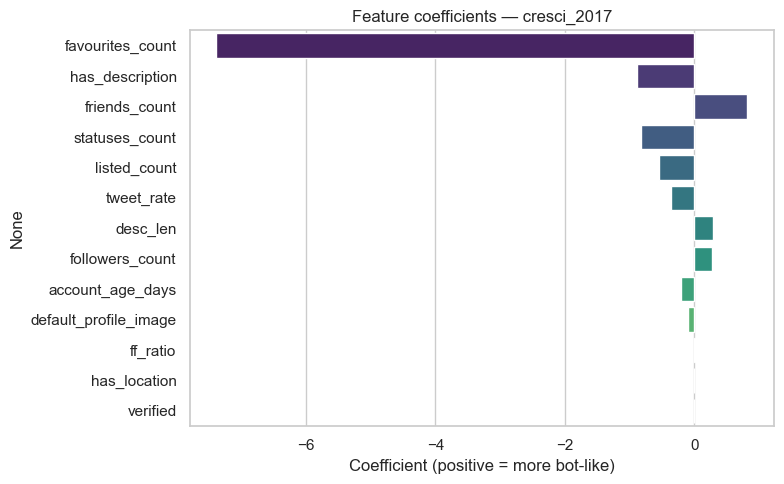

favourites_count        -7.3798
has_description         -0.8800
friends_count            0.8190
statuses_count          -0.8186
listed_count            -0.5467
tweet_rate              -0.3561
desc_len                 0.2888
followers_count          0.2690
account_age_days        -0.2029
default_profile_image   -0.0939
ff_ratio                 0.0134
has_location            -0.0100
verified                 0.0000
dtype: float64


In [ ]:
lr = pipeline.named_steps["clf"]
coefficients = pd.Series(lr.coef_[0], index=X.columns)
coefficients = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=coefficients.values,
    y=coefficients.index,
    hue=coefficients.index,
    palette="viridis",
    dodge=False,
    legend=False,
)
plt.title(f"Feature coefficients — {DATASET}")
plt.xlabel("Coefficient (positive = more bot-like)")
plt.tight_layout()
plt.show()

print(coefficients.round(4))


## 9. Save the model


In [88]:
os.makedirs(os.path.dirname(MODEL_OUT), exist_ok=True)

with open(MODEL_OUT, "wb") as f:
    pickle.dump(pipeline, f)

print(f"Model saved → {MODEL_OUT}")


Model saved → /Users/hsla/Desktop/cresci_2017_logisticRegression.pkl


## 10. Quick inference example


In [89]:
with open(MODEL_OUT, "rb") as f:
    loaded_model = pickle.load(f)

example = pd.DataFrame([{
    "followers_count":       150,
    "friends_count":         12000,
    "statuses_count":        50000,
    "favourites_count":      0,
    "listed_count":          1,
    "ff_ratio":              150 / (12000 + 1),
    "tweet_rate":            50000 / 365,
    "account_age_days":      365,
    "verified":              0,
    "default_profile_image": 1,
    "desc_len":              0,
    "has_description":       0,
    "has_location":          0,
}])

prob = loaded_model.predict_proba(example)[0, 1]
pred = "bot" if prob >= 0.5 else "human"
print(f"Prediction: {pred}  (bot probability: {prob:.1%})")


example = pd.DataFrame([{
    "followers_count":       2500,
    "friends_count":         400,
    "statuses_count":        3200,
    "favourites_count":      1800,
    "listed_count":          25,
    "ff_ratio":              2500 / (400 + 1),
    "tweet_rate":            3200 / 3650,
    "account_age_days":      3650,
    "verified":              0,
    "default_profile_image": 0,
    "desc_len":              80,
    "has_description":       1,
    "has_location":          1,
}])

prob = loaded_model.predict_proba(example)[0, 1]
pred = "bot" if prob >= 0.5 else "human"
print(f"Prediction: {pred}  (human probability: {1 - prob:.1%})")

Prediction: human  (bot probability: 0.0%)
Prediction: human  (human probability: 81.9%)
